In [2]:
import os
import numpy as np
from pathlib import Path
import scipy.ndimage
import SimpleITK as sitk

import scipy.ndimage as ndi

def get_bounding_box(pet_array, ct_array):
    """
    改进的 3D 边界框裁剪算法，提取最大连通域，有效去除背景噪声和 CT 床板边缘。
    """
    # 1. 仅依赖 CT 来寻找身体轮廓。
    # 皮肤/肌肉的 HU 通常在 -100 到 +100 之间。
    # 使用 -500 可以安全地捕捉身体最外层的皮肤轮廓，同时完美过滤掉空气 (-1000) 和轻度散落噪声。
    body_mask = ct_array > -500
    
    # 2. 提取连通域 (Connected Components)
    # 这一步能有效消除视野(FOV)边缘的环状伪影或散落的体外物体
    labels, num_features = ndi.label(body_mask)
    if num_features == 0:
        return None
        
    # 3. 寻找体积最大的连通域 (忽略背景 0)
    counts = np.bincount(labels.ravel())
    counts[0] = 0  # 将背景的数量设为 0
    largest_component_label = counts.argmax()
    
    # 生成纯净的身体 Mask
    clean_body_mask = (labels == largest_component_label)
    
    # 4. 获取紧凑的坐标边界
    z_indices, y_indices, x_indices = np.where(clean_body_mask)
    
    if len(z_indices) == 0:
        return None
        
    z_min, z_max = z_indices.min(), z_indices.max()
    y_min, y_max = y_indices.min(), y_indices.max()
    x_min, x_max = x_indices.min(), x_indices.max()
    
    # 5. 添加少许 Padding (比如 3 个 voxel，防止外轮廓紧贴导致卷积特征丢失)
    pad = 3
    z_min, z_max = max(0, z_min - pad), min(pet_array.shape[0], z_max + pad + 1)
    y_min, y_max = max(0, y_min - pad), min(pet_array.shape[1], y_max + pad + 1)
    x_min, x_max = max(0, x_min - pad), min(pet_array.shape[2], x_max + pad + 1)
    
    return slice(z_min, z_max), slice(y_min, y_max), slice(x_min, x_max)

def normalize_volume(volume, method='z-score'):
    """
    Normalizes a 3D volume using either Z-score or Min-Max scaling.
    """
    if method == 'z-score':
        mu = np.mean(volume)
        sigma = np.std(volume)
        if sigma == 0:
            return volume - mu
        return (volume - mu) / sigma
    elif method == 'min-max':
        v_min = np.min(volume)
        v_max = np.max(volume)
        if v_max - v_min == 0:
            return volume - v_min
        return (volume - v_min) / (v_max - v_min)
    else:
        raise ValueError("Method must be 'z-score' or 'min-max'")

def process_autopet_dataset():
    """
    Standalone preprocessing pipeline for the AutoPET dataset.
    Uses recursive globbing to handle nested scan directories.
    """
    # 1. Define source and target directories
    source_base = Path('/data17/user/mx79/01.Dataset_AutoPET2025_FDG')
    target_base = Path('/gluon4/xl693/PETCTfoundation/AutoPET')
    
    # Corrected target spacing: (Z=3.0, Y=2.0, X=2.0)
    target_spacing_zyx = np.array([3.0, 2.0, 2.0])
    
    print(f"Starting AutoPET preprocessing...")
    print(f"Source: {source_base}")
    print(f"Target: {target_base}\n")
    
    if not source_base.exists():
        print(f"Error: Source directory {source_base} does not exist.")
        return

    # 2. Use rglob to recursively find all PET.nii.gz files, no matter how deep
    for pet_path in source_base.rglob('PET.nii.gz'):
        # The folder containing the PET file is our working scan directory
        scan_dir = pet_path.parent
        
        # Look for the CT file in the same directory
        ct_path = scan_dir / 'CT_resample.nii.gz'
        if not ct_path.exists():
            ct_path = scan_dir / 'CT.nii.gz'

        if ct_path.exists():
            try:
                # Maintain original nested folder structure for saving
                relative_dir = scan_dir.relative_to(source_base)
                save_path = target_base / relative_dir / 'PET.npy'
                
                print(f"Processing scan: {relative_dir}")
                
                # ---------------- Load Data & Extract Metadata ----------------
                pet_img = sitk.ReadImage(str(pet_path))
                ct_img = sitk.ReadImage(str(ct_path))
                
                spacing_xyz = pet_img.GetSpacing()
                spacing_xyz_rounded = np.round(spacing_xyz).astype(float)
                
                pet_array = sitk.GetArrayFromImage(pet_img).astype(np.float32)
                ct_array = sitk.GetArrayFromImage(ct_img).astype(np.float32)
                
                orig_spacing_zyx = np.array([
                    spacing_xyz_rounded[2], 
                    spacing_xyz_rounded[1], 
                    spacing_xyz_rounded[0]
                ])
                
                # ---------------- Resampling ----------------
                zoom_factors_pet = orig_spacing_zyx / target_spacing_zyx
                pet_resampled = scipy.ndimage.zoom(pet_array, zoom_factors_pet, order=1)
                
                zoom_factors_ct = np.array(pet_resampled.shape) / np.array(ct_array.shape)
                ct_resampled = scipy.ndimage.zoom(ct_array, zoom_factors_ct, order=1)
                
                # ---------------- Cropping ----------------
                bbox = get_bounding_box(pet_resampled, ct_resampled)
                if bbox is not None:
                    pet_cropped = pet_resampled[bbox]
                    ct_cropped = ct_resampled[bbox]
                else:
                    pet_cropped, ct_cropped = pet_resampled, ct_resampled
                    
                # ---------------- Normalization & Stacking ----------------
                pet_norm = normalize_volume(pet_cropped, method='z-score')
                ct_norm = normalize_volume(ct_cropped, method='z-score')
                
                stacked_volume = np.stack([pet_norm, ct_norm], axis=0)
                
                # ---------------- Saving ----------------
                save_path.parent.mkdir(parents=True, exist_ok=True)
                np.save(save_path, stacked_volume)
                
                print(f"  -> Extracted Spacing (XYZ): {spacing_xyz} -> Rounded: {spacing_xyz_rounded}")
                print(f"  -> Saved to: {save_path}")
                print(f"  -> Final Tensor Shape: {stacked_volume.shape}\n")
                
            except Exception as e:
                print(f"  -> [Error] Failed processing {scan_dir.name}: {e}\n")

if __name__ == '__main__':
    process_autopet_dataset()
    print("AutoPET dataset processing complete.")

Starting AutoPET preprocessing...
Source: /data17/user/mx79/01.Dataset_AutoPET2025_FDG
Target: /gluon4/xl693/PETCTfoundation/AutoPET

Processing scan: fdg_92c3de23f5_10-08-2005-NA-PET-CT Ganzkoerper  primaer mit KM-07499
  -> Extracted Spacing (XYZ): (2.0364201068878174, 2.0364201068878174, 3.0) -> Rounded: [2. 2. 3.]
  -> Saved to: /gluon4/xl693/PETCTfoundation/AutoPET/fdg_92c3de23f5_10-08-2005-NA-PET-CT Ganzkoerper  primaer mit KM-07499/PET.npy
  -> Final Tensor Shape: (2, 312, 182, 251)

Processing scan: fdg_cab58c1fee_03-19-2007-NA-PET-CT Ganzkoerper  primaer mit KM-35336
  -> Extracted Spacing (XYZ): (2.0364201068878174, 2.0364201068878174, 3.0) -> Rounded: [2. 2. 3.]
  -> Saved to: /gluon4/xl693/PETCTfoundation/AutoPET/fdg_cab58c1fee_03-19-2007-NA-PET-CT Ganzkoerper  primaer mit KM-35336/PET.npy
  -> Final Tensor Shape: (2, 634, 195, 238)

Processing scan: fdg_5c35fcbe89_08-10-2002-NA-PET-CT Ganzkoerper  primaer mit KM-30248
  -> Extracted Spacing (XYZ): (2.0364201068878174, 2.03

Loading Scan 1 (fdg_92c3...)...
  -> Tensor Shape: (2, 312, 182, 251)
  -> PET Channel (0) - Mean: 0.0000, Std: 1.0000
  -> CT  Channel (1) - Mean: 0.0000, Std: 1.0000

Loading Scan 2 (fdg_cab5...)...
  -> Tensor Shape: (2, 284, 175, 181)
  -> PET Channel (0) - Mean: -0.0000, Std: 1.0000
  -> CT  Channel (1) - Mean: 0.0000, Std: 1.0000



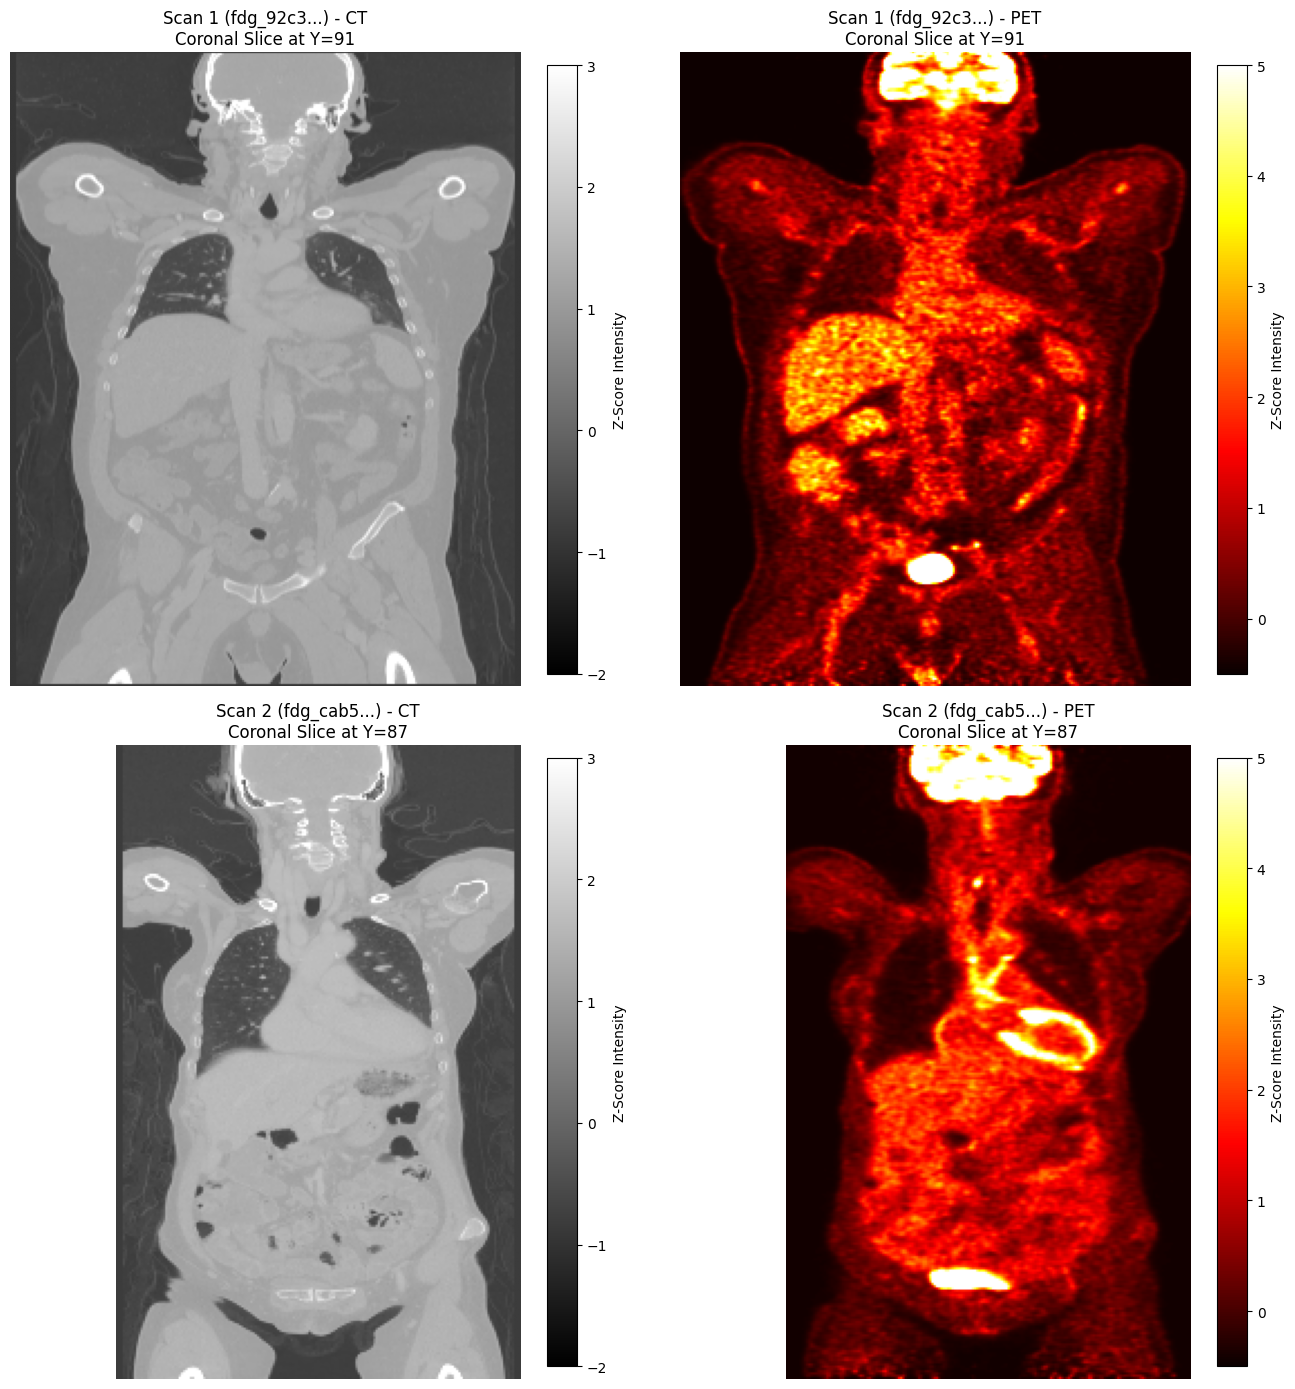

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def verify_and_plot_processed_data():
    # 1. Define the exact paths from your log output
    file1 = '/gluon4/xl693/PETCTfoundation/AutoPET/fdg_92c3de23f5_10-08-2005-NA-PET-CT Ganzkoerper  primaer mit KM-07499/PET.npy'
    file2 = '/gluon4/xl693/PETCTfoundation/AutoPET/fdg_cb1f5e74ab_06-14-2001-NA-PET-CT Ganzkoerper  primaer mit KM-39650/PET.npy'
    
    paths = [file1, file2]
    scan_labels = ['Scan 1 (fdg_92c3...)', 'Scan 2 (fdg_cab5...)']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 14))
    
    for i, path in enumerate(paths):
        print(f"Loading {scan_labels[i]}...")
        
        # Load the 4D tensor: Shape (C, Z, Y, X)
        data = np.load(path)
        
        # Verify normalization statistics (Should be close to mu=0, sigma=1)
        print(f"  -> Tensor Shape: {data.shape}")
        print(f"  -> PET Channel (0) - Mean: {data[0].mean():.4f}, Std: {data[0].std():.4f}")
        print(f"  -> CT  Channel (1) - Mean: {data[1].mean():.4f}, Std: {data[1].std():.4f}\n")
        
        # 2. Extract the Coronal Slice
        # Find the midpoint of the Y-axis (Anterior-Posterior dimension)
        y_mid = data.shape[2] // 2
        
        pet_coronal = data[0, :, y_mid, :]
        ct_coronal = data[1, :, y_mid, :]
        
        # 3. Plot CT (Left Column)
        ax_ct = axes[i, 0]
        # We use vmin/vmax to clip extreme values so soft tissue remains visible after Z-scoring
        im_ct = ax_ct.imshow(ct_coronal, cmap='gray', origin='lower', vmin=-2, vmax=3)
        ax_ct.set_title(f"{scan_labels[i]} - CT\nCoronal Slice at Y={y_mid}")
        ax_ct.axis('off')
        fig.colorbar(im_ct, ax=ax_ct, fraction=0.046, pad=0.04, label='Z-Score Intensity')
        
        # 4. Plot PET (Right Column)
        ax_pet = axes[i, 1]
        im_pet = ax_pet.imshow(pet_coronal, cmap='hot', origin='lower', vmin=-0.5, vmax=5)
        ax_pet.set_title(f"{scan_labels[i]} - PET\nCoronal Slice at Y={y_mid}")
        ax_pet.axis('off')
        fig.colorbar(im_pet, ax=ax_pet, fraction=0.046, pad=0.04, label='Z-Score Intensity')

    plt.tight_layout()
    plt.show()

# Execute the visualization
verify_and_plot_processed_data()